# Data Science Technical Challenge

## Introduction

In this test task you will have an opportunity to demonstrate your skills of a Data Scientist from various angles - processing data, analyzing and vizalizing it, finding insights, applying predictive techniques and explaining your reasoning about it.

The task is based around a bike sharing dataset openly available at UCI Machine Learning Repository [1].

Please go through the steps below, build up the necessary code and comment on your choices.

## Part 1 - Data Loading and Environment Preparation

**Tasks:**
1. Prepare a Python 3 virtual environment (with virtualenv command). requirements.txt output of pip freeze command should be included as part of your submission.
2. Load the data from UCI Repository and put it into the same folder with the notebook. The link to it is https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset . Here is an available mirror in case the above website is down: https://data.world/uci/bike-sharing-dataset
3. We split the data into two parts. One dataset containing the last 30 days and one dataset with the rest.

The analysis uses `day.csv`, as required by the task. The hourly dataset is kept in the raw data folder for completeness but is not used.

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("data/raw/day.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("day.csv")

# Read the raw data
df_all = pd.read_csv(DATA_PATH, parse_dates=["dteday"])

# Ensure chronological order before splitting
df_all = df_all.sort_values("dteday").reset_index(drop=True)

# Split into holdout set and development set
df_test = df_all.tail(30).copy()
df = df_all.iloc[:-30].copy()

# Split dataset
# df_last30 = df_all.tail(30)
# df = df_all.iloc[:-30, :]

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Part 2 - Data Processing and Analysis

**Tasks:**
1. Perform all needed steps to load and clean the data. Please comment the major steps of your code.
2. Visualise rentals of bikes per day.
3. Assume that each bike has exactly maximum 12 rentals per day.
    * Find the maximum number of bicycles `nmax` that was needed in any one day.
    * Find the 95%-percentile of bicycles `n95` that was needed in any one day.
5. Visualize the distribution of the covered days depending on the number of available bicycles (e.g. `nmax` bicycles would cover 100% of days, `n95` covers 95%, etc.)


#### 2.1 Data Cleaning

In [15]:
# Data quality checks
print("Full dataset shape:", df_all.shape)
print("Development dataset shape:", df.shape)
print("Test dataset shape:", df_test.shape)

print("\nDate range full dataset:")
print(df_all["dteday"].min(), "to", df_all["dteday"].max())

print("\nDate range development dataset:")
print(df["dteday"].min(), "to", df["dteday"].max())

print("\nDate range test dataset:")
print(df_test["dteday"].min(), "to", df_test["dteday"].max())

print("\nMissing values:")
display(df_all.isna().sum())

print("\nDuplicate rows:")
print(df_all.duplicated().sum())

print("\nDuplicate dates:")
print(df_all["dteday"].duplicated().sum())

print("\nData types:")
display(df_all.dtypes)

print("\nSummary statistics:")
display(df_all.describe())

Full dataset shape: (731, 16)
Development dataset shape: (701, 16)
Test dataset shape: (30, 16)

Date range full dataset:
2011-01-01 00:00:00 to 2012-12-31 00:00:00

Date range development dataset:
2011-01-01 00:00:00 to 2012-12-01 00:00:00

Date range test dataset:
2012-12-02 00:00:00 to 2012-12-31 00:00:00

Missing values:


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Duplicate rows:
0

Duplicate dates:
0

Data types:


instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


Summary statistics:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [16]:
# Check target composition
target_check = (df_all["casual"] + df_all["registered"] == df_all["cnt"]).all()
print(f"casual + registered equals cnt for all rows: {target_check}")

casual + registered equals cnt for all rows: True


- The dataset contains 731 daily observations from 2011-01-01 to 2012-12-31.
- No missing values or duplicate dates were found.
- The numerical ranges are plausible: weather and calendar variables are within their expected encoded ranges, and the normalized weather variables are between 0 and 1.
- The weather variables are already normalized in the source data. Since normalization was performed using predefined scale constants, the observed maximum values do not necessarily equal 1.
- The target variable `cnt` is equal to the sum of `casual` and `registered` for all rows. Therefore, `casual` and `registered` are excluded from the prediction features to avoid target leakage.

#### 2.2 Rentals per day

- The following plot shows the daily total number of bike rentals. The final 30 days are held out as test data and are highlighted separately.

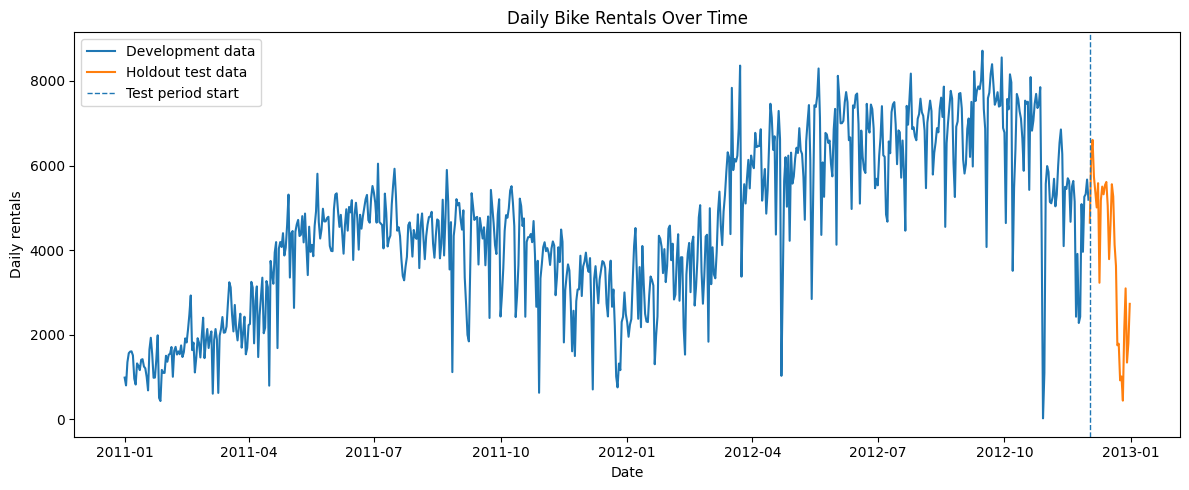

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["dteday"], df["cnt"], label="Development data")
ax.plot(df_test["dteday"], df_test["cnt"], label="Holdout test data")

ax.axvline(df_test["dteday"].min(), linestyle="--", linewidth=1, label="Test period start")

ax.set_title("Daily Bike Rentals Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Daily rentals")
ax.legend()

plt.tight_layout()
plt.show()

- Daily rentals show a clear seasonal pattern, with substantially higher demand during warmer months and lower demand during winter. The holdout period covers the final 30 days of the time series and is kept separate for model evaluation.

#### 2.3.1 `nmax` - Maximum required fleet size

- Assume that one bike can serve up to 12 rentals per day.
- The required minimal number of bikes for each day is calculated as the daily rental count divided by 12 and rounded up to the next integer.
- `nmax` is the maximum required fleet size observed in the development data. It represents the fleet size needed to cover 100% of observed daily demand in that period.
- To keep the final 30 days strictly reserved for model evaluation, all descriptive fleet-size calculations are performed on the development data only.

In [18]:
RENTALS_PER_BIKE_PER_DAY = 12

df = df.copy()
df["required_bikes"] = np.ceil(df["cnt"] / RENTALS_PER_BIKE_PER_DAY).astype(int)

nmax = df["required_bikes"].max()

peak_days = df.loc[df["required_bikes"] == nmax, ["dteday", "cnt", "required_bikes"]]

print(f"Maximum required fleet size (nmax): {nmax} bikes")
display(peak_days)

Maximum required fleet size (nmax): 727 bikes


,dteday,cnt,required_bikes
623,2012-09-15,8714,727


- The maximum required fleet size in the development period is 727 bikes. This value would be sufficient to cover rental demand on all observed development days, but it is driven by the single highest-demand day and may therefore be conservative for regular operations.

#### 2.3.2 `n95` - Fleet size required to cover 95% of observed days

- `n95` is defined as the smallest fleet size that covers at least 95% of observed daily demand in the development data.
- Compared with nmax, this is less driven by rare peak-demand days and may therefore be more relevant for regular fleet planning.

In [19]:
# Fleet size required to cover at least 95% of development days
n95 = int(df["required_bikes"].quantile(0.95, interpolation="higher"))

covered_days_n95 = (df["required_bikes"] <= n95).sum()
total_days = len(df)
coverage_n95 = covered_days_n95 / total_days

uncovered_days_n95 = total_days - covered_days_n95

print(f"Fleet size covering at least 95% of development days (n95): {n95} bikes")
print(f"Covered days: {covered_days_n95} / {total_days} ({coverage_n95:.1%})")
print(f"Days not fully covered: {uncovered_days_n95} / {total_days} ({1 - coverage_n95:.1%})")

Fleet size covering at least 95% of development days (n95): 632 bikes
Covered days: 666 / 701 (95.0%)
Days not fully covered: 35 / 701 (5.0%)


In [20]:
fleet_summary = pd.DataFrame(
    {
        "Metric": ["n95", "nmax"],
        "Description": [
            "Smallest fleet size covering at least 95% of development days",
            "Fleet size covering 100% of development days",
        ],
        "Available bikes": [n95, nmax],
        "Covered days": [
            (df["required_bikes"] <= n95).sum(),
            (df["required_bikes"] <= nmax).sum(),
        ],
        "Coverage": [
            (df["required_bikes"] <= n95).mean(),
            (df["required_bikes"] <= nmax).mean(),
        ],
    }
)

fleet_summary["Coverage"] = fleet_summary["Coverage"].map("{:.1%}".format)

display(fleet_summary)

,Metric,Description,Available bikes,Covered days,Coverage
0,n95,Smallest fleet size covering at least 95% of d...,632,666,95.0%
1,nmax,Fleet size covering 100% of development days,727,701,100.0%


- `n95` provides a more balanced operational planning estimate than `nmax`: it covers at least 95% of observed development days while avoiding fleet sizing based solely on the single highest-demand day.
- `nmax`, in contrast, represents the fleet size required to cover all observed development days.

#### 2.4 Coverage depending on available fleet size

- The following plot shows the share of development days that can be fully covered depending on the number of available bikes.
- For a given fleet size, a day is considered covered if the available number of bikes is at least as large as the required number of bikes for that day.
- By definition, `nmax` covers 100% of observed development days, while `n95` is the smallest fleet size covering at least 95% of days.

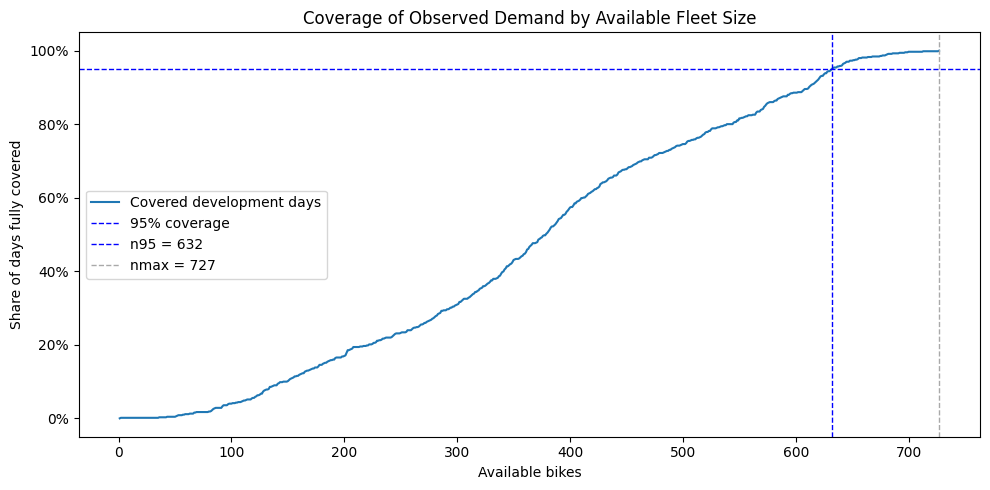

In [21]:
from matplotlib.ticker import PercentFormatter

# Coverage curve: share of days fully covered for each possible fleet size
fleet_sizes = np.arange(1, nmax + 1)

coverage = [
    (df["required_bikes"] <= fleet_size).mean()
    for fleet_size in fleet_sizes
]

coverage_df = pd.DataFrame(
    {
        "available_bikes": fleet_sizes,
        "covered_days_share": coverage,
    }
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    coverage_df["available_bikes"],
    coverage_df["covered_days_share"],
    label="Covered development days",
)

# Reference lines for n95 and nmax
ax.axhline(0.95, linestyle="--", linewidth=1, label="95% coverage", color="blue")
ax.axvline(n95, linestyle="--", linewidth=1, label=f"n95 = {n95}", color="blue")
ax.axvline(nmax, linestyle="--", linewidth=1, label=f"nmax = {nmax}", color="darkgrey")

ax.set_title("Coverage of Observed Demand by Available Fleet Size")
ax.set_xlabel("Available bikes")
ax.set_ylabel("Share of days fully covered")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
OUTPUT_FIG_DIR = Path("outputs/figures")
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(OUTPUT_FIG_DIR / "fleet_size_coverage_curve.png", dpi=300, bbox_inches="tight")

- The coverage curve shows the trade-off between fleet size and service coverage.
- Increasing the fleet size improves the share of days that can be fully covered, but the marginal benefit decreases as coverage approaches 100%.
- `n95` provides a pragmatic planning level that covers at least 95% of observed development days, while `nmax` covers all observed development days but is driven by the highest-demand day.

## Part 3 - Building prediction models

**Tasks:**
1. Define a test metric for predicting the daily demand for bike sharing, which you would like to use to measure the accuracy of the constructed models, and explain your choice.
2. Build a demand prediction model with Random Forest, preferably making use of following python libraries: scikit-learn. 
3. Report the value of the chosen test metric on the provided data. 

#### 3.1 Define Test Metric

- I use the Mean Absolute Error as the primary test metric for predicting daily bike rental demand.
- MAE measures the average absolute difference between predicted and observed daily rentals. This makes it directly interpretable in business terms: an MAE of 500 means that the model is off by 500 rentals per day on average.
- It is suitable for fleet planning because the output variable is an absolute demand count. Compared with squared-error metrics, MAE is less dominated by individual high-demand days, while still measuring all forecast errors in the same unit as the target variable.
- As an additional diagnostic metric, RMSE is reported as well. RMSE penalizes large errors stronger than MAE, which is relevant because large forecast errors on peak-demand days can be operationally costly.
- R² is also reported as a supplementary goodness-of-fit metric. It indicates how much of the variation in daily demand is explained by the model on the holdout data. However, it is less valuable for fleet planning compared to MAE because it does not express the error in number of rentals.

#### 3.2 Random Forest Prediction Model

- A Random Forest Regressor is used to predict daily bike rental demand (`cnt`).
- The model is trained on the development data and evaluated on the final 30-day holdout period.
- The columns `casual` and `registered` are excluded because their sum equals the target variable `cnt`, which would create target leakage.
- The date column and record index are also excluded from the feature set. Calendar and weather variables are used as predictors.

Model design choices:
- Calendar and encoded discrete variables such as `season`, `yr`, `mnth`, `weekday`, `holiday`, `workingday`, and `weathersit` are treated as categorical features because their numeric values represent categories rather than continuous magnitudes.
- Weather-related variables such as `temp`, `atemp`, `hum`, and `windspeed` are treated as numerical features because they represent continuous measurements.
- The categorical variables are one-hot encoded to avoid imposing an artificial ordinal relationship between categories, for example between months or weekdays.
- The Random Forest uses 500 trees (`n_estimators=500`) to reduce prediction variance and make results more stable. Increasing the number of trees usually improves stability, while the additional computational cost is negligible for this small dataset.
- `min_samples_leaf=3` is used as a light regularisation parameter. It prevents individual trees from creating very small leaf nodes based on only one or two observations, which can reduce overfitting and improve generalisation.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Define target and feature columns
target = "cnt"

categorical_features = [
    "yr",
    "season",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
]

numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

excluded_columns = [
    "instant",
    "dteday",
    "casual",
    "registered",
    "cnt",
    "required_bikes",  # created in Part 2, not an input feature
]

feature_columns = categorical_features + numeric_features

X_train = df[feature_columns]
y_train = df[target]

X_test = df_test[feature_columns]
y_test = df_test[target]

# Preprocessing: one-hot encode categorical variables; pass numeric variables through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

# Random Forest model
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,       # More trees improve prediction stability
                random_state=42,        # Ensures reproducible results
                min_samples_leaf=3,     # Light regularization to reduce overfitting
                n_jobs=-1,              # Use all available CPU cores
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model fitted successfully.")
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Random Forest model fitted successfully.
Training observations: 701
Test observations: 30


#### 3.3 Model Evaluation

- The model is evaluated on the final 30 days of the time series, which were held out before the exploratory analysis and model training.
- MAE is used as the primary test metric, with RMSE and R² reported as additional diagnostics.
- A simple mean-demand baseline is included to contextualise the Random Forest performance.
- The mean baseline is intentionally simple and used as a minimum benchmark. In a production forecasting setup, I would additionally compare against seasonal naive or rolling-window baselines

In [24]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate_predictions(y_true, y_pred, model_name):
    return pd.DataFrame(
        {
            "Model": [model_name],
            "MAE": [mean_absolute_error(y_true, y_pred)],
            "RMSE": [root_mean_squared_error(y_true, y_pred)],
            "R²": [r2_score(y_true, y_pred)],
        }
    )

# Baseline: predict the average demand observed in the development data
y_pred_baseline = np.repeat(y_train.mean(), len(y_test))

baseline_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_baseline,
    model_name="Mean baseline",
)

rf_results = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_rf,
    model_name="Random Forest",
)

model_results = pd.concat([baseline_results, rf_results], ignore_index=True)

display(model_results)

,Model,MAE,RMSE,R²
0,Mean baseline,1532.197242,1880.237741,-0.104086
1,Random Forest,787.349486,1006.419279,0.683674


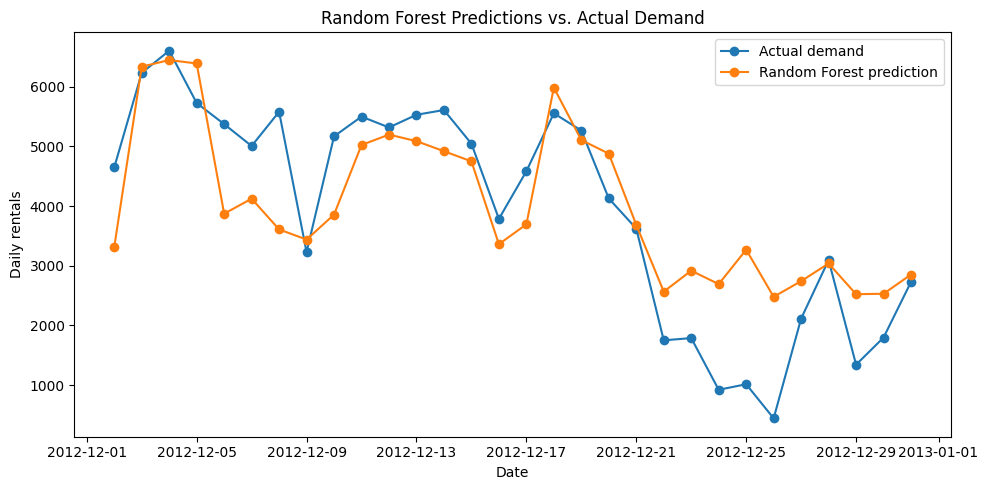

In [25]:
prediction_df = df_test[["dteday", "cnt"]].copy()
prediction_df["predicted_cnt"] = y_pred_rf

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    prediction_df["dteday"],
    prediction_df["cnt"],
    marker="o",
    label="Actual demand",
)

ax.plot(
    prediction_df["dteday"],
    prediction_df["predicted_cnt"],
    marker="o",
    label="Random Forest prediction",
)

ax.set_title("Random Forest Predictions vs. Actual Demand")
ax.set_xlabel("Date")
ax.set_ylabel("Daily rentals")
ax.legend()

plt.tight_layout()
plt.show()

In [26]:
prediction_df["absolute_error"] = (
    prediction_df["cnt"] - prediction_df["predicted_cnt"]
).abs()

display(prediction_df.sort_values("absolute_error", ascending=False).head(10))

,dteday,cnt,predicted_cnt,absolute_error
724,2012-12-25,1013,3269.168080,2256.168080
725,2012-12-26,441,2479.121157,2038.121157
707,2012-12-08,5582,3609.271470,1972.728530
723,2012-12-24,920,2692.107798,1772.107798
705,2012-12-06,5375,3872.593222,1502.406778
701,2012-12-02,4649,3312.393608,1336.606392
709,2012-12-10,5170,3857.912909,1312.087091
728,2012-12-29,1341,2522.823073,1181.823073
722,2012-12-23,1787,2917.176456,1130.176456
716,2012-12-17,4585,3694.347782,890.652218


Remarks:
- The Random Forest clearly outperforms the simple mean baseline on the 30-day holdout period. Its MAE of approximately 789 means that the model is off by around 789 daily rentals on an average test day.
- The RMSE is higher than the MAE, indicating that some individual days have larger forecast errors. This is plausible in the December holdout period, where holiday effects and short-term demand fluctuations may not be fully captured by the available calendar and weather variables.
- Overall, the model provides a useful demand estimate for operational planning, although additional event-specific and holiday-related features could further improve performance.

## Part 4 - Reflection / comments

**Tasks:** (Optional) Please share with us any free form reflection, comments or feedback you have in the context of this test task.
- The task is a useful simplified example of operational demand forecasting. The Random Forest model provides a reasonable first demand estimate, but I would not treat it as a final production-level forecasting solution without further validation.
- One important limitation is that the model only uses the provided calendar and weather variables. In a real operational setting, additional features such as local events, school holidays, promotions, station-level availability, pricing effects, or even more granular weather forecasts could improve predictive performance.
- The final 30-day holdout also gives only a limited view of generalisation performance, especially because it covers a specific seasonal period.
- For fleet planning, the prediction model should ideally be combined with something like a cost-based decision framework. For example, the optimal number of bikes depends not only on predicted demand, but also on the cost of additional bikes, the cost of unmet demand, service-level targets, and operational constraints. In this task, `n95` and `nmax` provide useful descriptive planning benchmarks, but a real business decision would require explicit trade-offs between service coverage and fleet cost.

## Submission

Please submit this notebook with your developments in .ipynb and .html formats as well as your requirements.txt file.

## References

[1] Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.